# Figure 4 v5 — XGBoost Cell Number Assay: VR vs Open Field

Loads data from both Eddie assay directories and runs the same baseline pR² analysis for each session type:
- **VR**: `data/eddie/xgboost_cell_number_assay/` — baselines: pos, speed, lfp + combinations
- **OF**: `data/eddie/xgboost_cell_number_assay_of/` — baselines: pos, speed, hd, hing, lfp + combinations

For each session type the figure shows:
- **Panel 1** (wide): Baseline pR² bars — GC vs NGS targets + medial vs lateral (ENTm only)
- **Panels 2–5**: Line plots of pR² vs n_covariate_cells, one per (target × covariate type)
- **Panel 6**: Δ pR² summary boxplot at n=10

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
import os, glob, warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

COL_GC      = '#c04744'
COL_NGS     = '#3171ae'
COL_GC_MED  = '#c04744'
COL_GC_LAT  = '#e8a0a0'
COL_NGS_MED = '#3171ae'
COL_NGS_LAT = '#88b4d4'
GROUP_COLOR = {
    'GC\u2192GC':   COL_GC,
    'GC\u2192NGS':  '#e58e38',
    'NGS\u2192GC':  '#88bbdd',
    'NGS\u2192NGS': COL_NGS,
}

DATA_ROOT      = '/Users/harryclark/Documents/spatial-manifolds/data'
VR_SRC         = os.path.join(DATA_ROOT, 'eddie', 'xgboost_cell_number_assay')
OF_SRC         = os.path.join(DATA_ROOT, 'eddie', 'xgboost_cell_number_assay_of')
CELL_CLASS_CSV = os.path.join(DATA_ROOT, 'cell_classifications.csv')
OUT_DIR        = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost'

ML_THRESH = 3400   # µm — |SC_x| threshold for medial vs lateral
MAX_N     = 10

## 1. Load data
Concatenates all CSVs from each assay directory. Caches the combined DataFrames so subsequent runs are fast.

In [2]:
def load_assay(src_dir, cache_csv):
    if os.path.exists(cache_csv):
        df = pd.read_csv(cache_csv)
        print(f'Loaded from cache: {cache_csv}  shape={df.shape}')
        return df
    files = glob.glob(os.path.join(src_dir, '*.csv'))
    dfs = []
    for f in files:
        try:
            d = pd.read_csv(f)
            if not d.empty:
                dfs.append(d)
        except Exception:
            pass
    df = pd.concat(dfs, ignore_index=True)
    df.to_csv(cache_csv, index=False)
    print(f'Built and cached: {cache_csv}  shape={df.shape}')
    return df

vr_raw = load_assay(VR_SRC, os.path.join(DATA_ROOT, 'xgboost_cell_number_assay_master_vr.csv'))
of_raw = load_assay(OF_SRC, os.path.join(DATA_ROOT, 'xgboost_cell_number_assay_master_of.csv'))

print('\nVR baselines :', sorted(vr_raw['baseline'].dropna().unique()))
print('OF baselines :', sorted(of_raw['baseline'].dropna().unique()))

Built and cached: /Users/harryclark/Documents/spatial-manifolds/data/xgboost_cell_number_assay_master_vr.csv  shape=(1067560, 8)
Built and cached: /Users/harryclark/Documents/spatial-manifolds/data/xgboost_cell_number_assay_master_of.csv  shape=(4116840, 8)

VR baselines : ['lfp', 'pos', 'pos_lfp', 'pos_speed', 'pos_speed_lfp', 'speed', 'speed_lfp']
OF baselines : ['hd', 'hing', 'lfp', 'pos', 'pos_hd', 'pos_hd_hing', 'pos_hing', 'pos_lfp', 'pos_speed', 'pos_speed_hd', 'pos_speed_hd_hing', 'pos_speed_hd_hing_lfp', 'pos_speed_hing', 'pos_speed_lfp', 'speed']


## 2. Session-type configuration
Baseline ordering (simple → complex) and short display labels for each session type.

In [3]:
# ── VR ────────────────────────────────────────────────────────────────────────
VR_BASELINE_ORDER = [
    'pos', 'speed', 'lfp',
    'pos_speed', 'pos_lfp', 'speed_lfp',
    'pos_speed_lfp',
]
VR_BASELINE_LABEL = {
    'pos':           'Pos',
    'speed':         'Speed',
    'lfp':           'LFP',
    'pos_speed':     'Pos+Spd',
    'pos_lfp':       'Pos+LFP',
    'speed_lfp':     'Spd+LFP',
    'pos_speed_lfp': 'Pos+Spd+LFP',
}
VR_MOST_COMPLEX = 'pos_speed_lfp'

# ── OF ────────────────────────────────────────────────────────────────────────
OF_BASELINE_ORDER = [
    'pos', 'speed', 'hd', 'hing', 'lfp',
    'pos_speed', 'pos_hd', 'pos_hing', 'pos_lfp',
    'pos_speed_hd_hing', 'pos_speed_hd_hing_lfp',
]
OF_BASELINE_LABEL = {
    'pos':                   'Pos',
    'speed':                 'Speed',
    'hd':                    'HD',
    'hing':                  'HiG',
    'lfp':                   'LFP',
    'pos_speed':             'Pos+Spd',
    'pos_hd':                'Pos+HD',
    'pos_hing':              'Pos+HiG',
    'pos_lfp':               'Pos+LFP',
    'pos_speed_hd_hing':     'Pos+Spd+HD+HiG',
    'pos_speed_hd_hing_lfp': 'Pos+Spd+HD+HiG+LFP',
}
OF_MOST_COMPLEX = 'pos_speed_hd_hing_lfp'

# colour palette keyed by baseline complexity (shared viridis ramp per session)
def make_bl_palette(baseline_order):
    return dict(zip(baseline_order,
                    plt.cm.viridis(np.linspace(0.15, 0.9, len(baseline_order)))))

VR_BL_PALETTE = make_bl_palette(VR_BASELINE_ORDER)
OF_BL_PALETTE = make_bl_palette(OF_BASELINE_ORDER)

## 3. Prepare data
Infer target type (cmGC / ncmGC / NGS) from covariate_type column, filter to known baselines,
and merge medial/lateral classification from `cell_classifications.csv`.

In [4]:
def infer_target_type(cov_set):
    if 'cmGC'  in cov_set: return 'cmGC'
    if 'ncmGC' in cov_set: return 'ncmGC'
    return 'NGS'


def prepare_data(raw, baseline_order, session_label):
    target_types = (
        raw.groupby(['mouse', 'day', 'target_cluster_id'])['covariate_type']
        .apply(lambda x: infer_target_type(set(x)))
        .reset_index()
        .rename(columns={'covariate_type': 'target_type'})
    )
    data = raw.merge(target_types, on=['mouse', 'day', 'target_cluster_id'], how='left')
    data['target_broad'] = data['target_type'].apply(
        lambda t: 'GC' if t in ('cmGC', 'ncmGC') else 'NGS')
    data = data[data['baseline'].isin(baseline_order)].copy()

    # Merge medial/lateral
    cc = pd.read_csv(
        CELL_CLASS_CSV,
        usecols=['mouse', 'day', 'cluster_id', 'SC_x', 'brain_region']
    ).rename(columns={'cluster_id': 'target_cluster_id'})
    cc = cc[cc['brain_region'].str.startswith('ENTm')].copy()
    cc['ml_pos'] = cc['SC_x'].abs()
    data = data.merge(cc[['mouse','day','target_cluster_id','ml_pos']],
                      on=['mouse','day','target_cluster_id'], how='left')
    data['ml_group'] = data['ml_pos'].apply(
        lambda y: 'Medial'  if pd.notna(y) and y < ML_THRESH else
                  'Lateral' if pd.notna(y) else np.nan)

    print(f'[{session_label}]  shape={data.shape}')
    print(f'  Target types: {data.drop_duplicates(["mouse","day","target_cluster_id"])["target_type"].value_counts().to_dict()}')
    print(f'  ML groups:    {data["ml_group"].value_counts().to_dict()}')
    return data


vr_data = prepare_data(vr_raw, VR_BASELINE_ORDER, 'VR')
of_data = prepare_data(of_raw, OF_BASELINE_ORDER, 'OF')

[VR]  shape=(1026424, 12)
  Target types: {'NGS': 4681, 'cmGC': 205, 'ncmGC': 128}
  ML groups:    {'Lateral': 659596, 'Medial': 238245}
[OF]  shape=(2900227, 12)
  Target types: {'NGS': 7292, 'cmGC': 424, 'ncmGC': 228}
  ML groups:    {'Lateral': 1700600, 'Medial': 737572}


## 4. Analysis functions
All parameterised by baseline_order / most_complex_bl so they work for both VR and OF.

In [5]:
def build_heatmap_data(data, target_broad, cov_type, baseline_order):
    """Returns bl_mean, bl_sem (per baseline at n=0) and hm (n_baselines × MAX_N)."""
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline'].isin(baseline_order))
    ].copy()
    n0 = (df[df['n_covariate_cells'] == 0]
          .drop_duplicates(subset=['mouse','day','target_cluster_id','baseline','covariate_cell_type']))
    bl_mean = n0.groupby('baseline')['pR2_cv'].mean().reindex(baseline_order)
    bl_sem  = n0.groupby('baseline')['pR2_cv'].sem().reindex(baseline_order)
    dfn = df[df['n_covariate_cells'].between(1, MAX_N)]
    hm  = (dfn.groupby(['baseline','n_covariate_cells'])['pR2_cv']
               .mean().unstack('n_covariate_cells')
               .reindex(index=baseline_order, columns=range(1, MAX_N+1)))
    return bl_mean, bl_sem, hm


def build_n0_combined(data):
    """n=0 baseline rows deduplicated per (mouse, day, target, baseline, cov_type)."""
    return (data[data['n_covariate_cells'] == 0]
            .drop_duplicates(subset=['mouse','day','target_cluster_id','baseline','covariate_cell_type']))


def cell_delta_at_max(data, target_broad, cov_type, most_complex_bl):
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline']            == most_complex_bl)
    ]
    uid   = ['mouse','day','target_cluster_id']
    pivot = df.pivot_table(index=uid, columns='n_covariate_cells', values='pR2_cv')
    pivot.columns = pivot.columns.astype(int)
    if 0 not in pivot.columns or MAX_N not in pivot.columns:
        return pd.DataFrame()
    valid = pivot[[0, MAX_N]].dropna().reset_index()
    valid['delta']        = valid[MAX_N] - valid[0]
    valid['target_broad'] = target_broad
    valid['cov_type']     = cov_type
    return valid


def build_summary_df(data, most_complex_bl):
    parts = [
        cell_delta_at_max(data, 'GC',  'GC',  most_complex_bl).assign(label='GC\u2192GC'),
        cell_delta_at_max(data, 'GC',  'NGS', most_complex_bl).assign(label='GC\u2192NGS'),
        cell_delta_at_max(data, 'NGS', 'GC',  most_complex_bl).assign(label='NGS\u2192GC'),
        cell_delta_at_max(data, 'NGS', 'NGS', most_complex_bl).assign(label='NGS\u2192NGS'),
    ]
    return pd.concat([p for p in parts if not p.empty], ignore_index=True)


def mean_pr2_by_n(data, target_broad, cov_type, baseline_order):
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline'].isin(baseline_order))
    ]
    return (df[df['n_covariate_cells'].between(0, MAX_N)]
            .groupby(['baseline','n_covariate_cells'])['pR2_cv']
            .agg(mean='mean', sem=lambda x: x.sem())
            .reset_index())


# ── Stat helpers ───────────────────────────────────────────────────────────────
def sig_star(p):
    if pd.isna(p):  return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'ns'


def mwu_p(a, b):
    a, b = a.dropna(), b.dropna()
    if len(a) < 3 or len(b) < 3: return np.nan
    return sp_stats.mannwhitneyu(a, b, alternative='two-sided').pvalue


print('Functions defined.')

Functions defined.


## 5. Master plotting function
Called once for VR, once for OF.

In [6]:
def make_session_figure(data, baseline_order, bl_label, most_complex_bl,
                        bl_palette, session_label, save_stem):
    """
    6-column figure for one session type.
    Col 0 (wide): GC vs NGS bars (top) + medial/lateral bars (bottom)
    Cols 1-4:     line plots (GC→GC, GC→NGS, NGS→GC, NGS→NGS)
    Col 5:        Δ pR² summary boxplot
    """
    n_bl    = len(baseline_order)
    bl_labs = [bl_label[b] for b in baseline_order]
    CI      = 1.96
    x       = np.arange(n_bl)
    GROUP_ORDER = ['GC\u2192GC', 'GC\u2192NGS', 'NGS\u2192GC', 'NGS\u2192NGS']

    # ── Build heatmap / n0 stats ───────────────────────────────────────────────
    gc_bl,  _, _ = build_heatmap_data(data, 'GC',  'GC',  baseline_order)
    ngs_bl, _, _ = build_heatmap_data(data, 'NGS', 'NGS', baseline_order)
    gc_sem  = (build_n0_combined(data)[(build_n0_combined(data)['target_broad']=='GC')  &
                                       (build_n0_combined(data)['covariate_cell_type']=='GC')]
               .groupby('baseline')['pR2_cv'].sem().reindex(baseline_order))
    ngs_sem = (build_n0_combined(data)[(build_n0_combined(data)['target_broad']=='NGS') &
                                       (build_n0_combined(data)['covariate_cell_type']=='NGS')]
               .groupby('baseline')['pR2_cv'].sem().reindex(baseline_order))
    n0c = build_n0_combined(data)
    pvals_bl = {bl: mwu_p(
        n0c[(n0c['target_broad']=='GC')  & (n0c['baseline']==bl)]['pR2_cv'],
        n0c[(n0c['target_broad']=='NGS') & (n0c['baseline']==bl)]['pR2_cv']
    ) for bl in baseline_order}

    # ── Medial / lateral stats ─────────────────────────────────────────────────
    def ml_stats(tgt, ml_grp, cov_type):
        sub = n0c[(n0c['target_broad']==tgt) & (n0c['ml_group']==ml_grp) &
                  (n0c['covariate_cell_type']==cov_type)]
        return sub.groupby('baseline')['pR2_cv'].agg(mean='mean', sem=lambda x: x.sem()).reindex(baseline_order)

    gc_med  = ml_stats('GC',  'Medial',  'GC')
    gc_lat  = ml_stats('GC',  'Lateral', 'GC')
    ngs_med = ml_stats('NGS', 'Medial',  'NGS')
    ngs_lat = ml_stats('NGS', 'Lateral', 'NGS')

    def ml_p(tgt, bl):
        return mwu_p(
            n0c[(n0c['target_broad']==tgt) & (n0c['ml_group']=='Medial')  & (n0c['baseline']==bl)]['pR2_cv'],
            n0c[(n0c['target_broad']==tgt) & (n0c['ml_group']=='Lateral') & (n0c['baseline']==bl)]['pR2_cv']
        )

    pvals_gc_ml  = {bl: ml_p('GC',  bl) for bl in baseline_order}
    pvals_ngs_ml = {bl: ml_p('NGS', bl) for bl in baseline_order}

    # ── Summary Δ pR² ─────────────────────────────────────────────────────────
    summary_df = build_summary_df(data, most_complex_bl)
    for lbl in GROUP_ORDER:
        sub = summary_df[summary_df['label']==lbl]
        print(f'  {lbl:12s}  n={len(sub):5d}  median Δ pR²={sub["delta"].median():.4f}')

    # ── Line plot data ─────────────────────────────────────────────────────────
    lp = {
        ('GC', 'GC'):   mean_pr2_by_n(data, 'GC',  'GC',  baseline_order),
        ('GC', 'NGS'):  mean_pr2_by_n(data, 'GC',  'NGS', baseline_order),
        ('NGS','GC'):   mean_pr2_by_n(data, 'NGS', 'GC',  baseline_order),
        ('NGS','NGS'):  mean_pr2_by_n(data, 'NGS', 'NGS', baseline_order),
    }

    # ── Layout ────────────────────────────────────────────────────────────────
    W0     = 2.5 * max(1.7, n_bl / 4)
    fig, axes = plt.subplots(
        2, 6,
        figsize=(22 + (W0 - 2.5) * 0.5, 8.8),
        gridspec_kw=dict(
            width_ratios=[W0, 2.0, 2.0, 2.0, 2.0, 1.8],
            hspace=0.50, wspace=0.30,
            left=0.06, right=0.97, top=0.90, bottom=0.10
        )
    )
    ax_bar, ax_l_gc_gc, ax_l_gc_ngs, ax_l_ngs_gc, ax_l_ngs_ngs, ax_dlt = axes[0]
    ax_ml = axes[1, 0]
    for col in range(1, 6):
        axes[1, col].set_visible(False)

    # ── Top bar: GC vs NGS ────────────────────────────────────────────────────
    w = 0.35
    ax_bar.bar(x - w/2, gc_bl,  yerr=CI*gc_sem,
               width=w, color=COL_GC,  alpha=0.80, edgecolor='#333', linewidth=0.5,
               error_kw=dict(elinewidth=1, capsize=3, ecolor='#333'), label='GC target')
    ax_bar.bar(x + w/2, ngs_bl, yerr=CI*ngs_sem,
               width=w, color=COL_NGS, alpha=0.80, edgecolor='#333', linewidth=0.5,
               error_kw=dict(elinewidth=1, capsize=3, ecolor='#333'), label='NGS target')
    ax_bar.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(bl_labs, rotation=35, ha='right', fontsize=8)
    ax_bar.set_ylabel('Baseline pR²', fontsize=9)
    ax_bar.set_ylim(bottom=min(0, gc_bl.min() - 0.01))
    ax_bar.set_title(f'{session_label} — Baseline pR²: GC vs NGS', fontsize=9, fontweight='bold')
    ax_bar.legend(fontsize=8, frameon=False)
    ax_bar.spines[['top','right']].set_visible(False)
    ax_bar.tick_params(labelsize=8)

    for xi, bl in enumerate(baseline_order):
        star = sig_star(pvals_bl[bl])
        if not star: continue
        gc_v  = float(gc_bl.iloc[xi])  + CI * float(gc_sem.iloc[xi])
        ngs_v = float(ngs_bl.iloc[xi]) + CI * float(ngs_sem.iloc[xi])
        y_top = max(gc_v, ngs_v) + 0.004
        ax_bar.plot([xi-w/2, xi+w/2], [y_top, y_top], color='k', lw=0.9)
        ax_bar.text(xi, y_top+0.001, star, ha='center', va='bottom', fontsize=8)

    # ── Bottom bar: Medial vs Lateral ─────────────────────────────────────────
    w4  = 0.20
    off = [-1.5*w4, -0.5*w4, 0.5*w4, 1.5*w4]
    bar_specs = [
        (gc_med,  COL_GC_MED,  'GC Medial'),
        (gc_lat,  COL_GC_LAT,  'GC Lateral'),
        (ngs_med, COL_NGS_MED, 'NGS Medial'),
        (ngs_lat, COL_NGS_LAT, 'NGS Lateral'),
    ]
    for (st, col, lbl), o in zip(bar_specs, off):
        ax_ml.bar(x + o, st['mean'], yerr=CI*st['sem'],
                  width=w4, color=col, alpha=0.85, edgecolor='#333', linewidth=0.4,
                  error_kw=dict(elinewidth=0.8, capsize=2, ecolor='#333'), label=lbl)

    for xi, bl in enumerate(baseline_order):
        for (tgt, st_med, st_lat, col_m, pv_dict) in [
            ('GC',  gc_med,  gc_lat,  COL_GC_MED,  pvals_gc_ml),
            ('NGS', ngs_med, ngs_lat, COL_NGS_MED, pvals_ngs_ml),
        ]:
            star = sig_star(pv_dict[bl])
            if not star: continue
            i0 = 0 if tgt == 'GC' else 2
            y_top = max(float(st_med.loc[bl,'mean']) + CI*float(st_med.loc[bl,'sem']),
                        float(st_lat.loc[bl,'mean']) + CI*float(st_lat.loc[bl,'sem'])) + 0.004
            ax_ml.plot([xi+off[i0], xi+off[i0+1]], [y_top, y_top], color=col_m, lw=0.9)
            ax_ml.text(xi+(off[i0]+off[i0+1])/2, y_top+0.001, star,
                       ha='center', va='bottom', fontsize=7, color=col_m)

    ax_ml.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_ml.set_xticks(x)
    ax_ml.set_xticklabels(bl_labs, rotation=35, ha='right', fontsize=8)
    ax_ml.set_ylabel('Baseline pR²', fontsize=9)
    ax_ml.set_ylim(bottom=min(0, gc_med['mean'].min() - 0.01))
    ax_ml.set_title(f'{session_label} — Medial (|SC_x|<{ML_THRESH}µm) vs Lateral — ENTm',
                    fontsize=9, fontweight='bold')
    ax_ml.legend(fontsize=7, frameon=False, ncol=2)
    ax_ml.spines[['top','right']].set_visible(False)
    ax_ml.tick_params(labelsize=8)

    # ── Line plots ────────────────────────────────────────────────────────────
    line_ax_specs = [
        (ax_l_gc_gc,   ('GC', 'GC'),   'GC',  'GC',  COL_GC),
        (ax_l_gc_ngs,  ('GC', 'NGS'),  'GC',  'NGS', COL_GC),
        (ax_l_ngs_gc,  ('NGS','GC'),   'NGS', 'GC',  COL_NGS),
        (ax_l_ngs_ngs, ('NGS','NGS'),  'NGS', 'NGS', COL_NGS),
    ]
    for ax, key, tgt_lbl, cov_lbl, tgt_col in line_ax_specs:
        lp_df = lp[key]
        for bl in baseline_order:
            sub = lp_df[lp_df['baseline']==bl].sort_values('n_covariate_cells')
            if sub.empty: continue
            c = bl_palette[bl]
            ax.plot(sub['n_covariate_cells'], sub['mean'], color=c, lw=2.0,
                    label=bl_label[bl])
            ax.fill_between(sub['n_covariate_cells'],
                            sub['mean']-sub['sem'], sub['mean']+sub['sem'],
                            color=c, alpha=0.18)
        ax.set_xlim(0, MAX_N); ax.set_xticks([0, 5, 10])
        ax.set_ylim(bottom=0)
        ax.set_xlabel(f'n {cov_lbl} covariate cells', fontsize=8)
        ax.set_ylabel('pR²', fontsize=9)
        ax.set_title(f'{tgt_lbl} target\n{cov_lbl} covariates',
                     fontsize=8.5, color=tgt_col, fontweight='bold')
        ax.axhline(0, color='#cccccc', lw=0.6, ls=':')
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=8)

    ax_l_gc_gc.legend(fontsize=6, frameon=False, ncol=1, loc='lower right',
                      title='Baseline', title_fontsize=6)
    for ax in [ax_l_gc_ngs, ax_l_ngs_gc, ax_l_ngs_ngs]:
        ax.set_ylabel('')
        ax.set_yticklabels([])

    # ── Δ pR² summary ─────────────────────────────────────────────────────────
    LABEL_MAP = {
        'GC\u2192GC':   'GC tgt\nGC cov',
        'GC\u2192NGS':  'GC tgt\nNGS cov',
        'NGS\u2192GC':  'NGS tgt\nGC cov',
        'NGS\u2192NGS': 'NGS tgt\nNGS cov',
    }
    summary_df['label_short'] = summary_df['label'].map(LABEL_MAP)
    label_short_order = [LABEL_MAP[g] for g in GROUP_ORDER]

    sns.boxplot(data=summary_df, x='label_short', y='delta',
                order=label_short_order,
                palette={LABEL_MAP[g]: GROUP_COLOR[g] for g in GROUP_ORDER},
                width=0.55, showfliers=False,
                medianprops=dict(color='#333333', lw=1.5), ax=ax_dlt)
    ax_dlt.axhline(0, color='#aaaaaa', lw=0.8, ls='--')
    ax_dlt.set_xlabel('')
    ax_dlt.set_ylabel(f'\u0394 pR\u00b2  (n={MAX_N} \u2212 n=0)', fontsize=9)
    ax_dlt.set_title(f'\u0394 pR\u00b2  n={MAX_N}\n{bl_label[most_complex_bl]}',
                     fontsize=8.5, fontweight='bold')
    ax_dlt.tick_params(axis='x', labelsize=7, rotation=20)
    ax_dlt.tick_params(axis='y', labelsize=8)
    ax_dlt.spines[['top','right']].set_visible(False)

    compare_pairs = [('GC\u2192GC','GC\u2192NGS'), ('NGS\u2192GC','NGS\u2192NGS'),
                     ('GC\u2192GC','NGS\u2192GC'), ('GC\u2192NGS','NGS\u2192NGS')]
    y_bracket, step = 0.115, 0.022
    for bi, (g1, g2) in enumerate(compare_pairs):
        x1 = label_short_order.index(LABEL_MAP[g1])
        x2 = label_short_order.index(LABEL_MAP[g2])
        d1 = summary_df[summary_df['label']==g1]['delta'].dropna()
        d2 = summary_df[summary_df['label']==g2]['delta'].dropna()
        if len(d1) < 3 or len(d2) < 3: continue
        p  = mwu_p(d1, d2)
        s  = sig_star(p)
        if not s: continue
        yb = y_bracket + bi * step
        ax_dlt.plot([x1,x1,x2,x2],[yb-0.003,yb,yb,yb-0.003], color='k', lw=0.9)
        ax_dlt.text((x1+x2)/2, yb+0.002, s, ha='center', va='bottom', fontsize=8)
    for xi, grp in enumerate(GROUP_ORDER):
        n = len(summary_df[summary_df['label']==grp])
        ax_dlt.text(xi, ax_dlt.get_ylim()[0]+0.001, f'n={n}', ha='center', va='bottom',
                    fontsize=6, color=GROUP_COLOR[grp])

    fig.suptitle(f'{session_label} — XGBoost baseline pR² assay', fontsize=10, fontweight='bold', y=1.01)
    out_path = os.path.join(OUT_DIR, f'{save_stem}.pdf')
    fig.savefig(out_path, bbox_inches='tight', dpi=300)
    print(f'Saved: {out_path}')
    plt.show()


print('Plotting function defined.')

Plotting function defined.


## 6. VR figure

VR summary Δ pR²:
  GC→GC         n=  251  median Δ pR²=0.0069
  GC→NGS        n=  331  median Δ pR²=0.0047
  NGS→GC        n= 3626  median Δ pR²=0.0035
  NGS→NGS       n= 4547  median Δ pR²=0.0038
Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/Figure4_v5_VR_baseline_assay.pdf


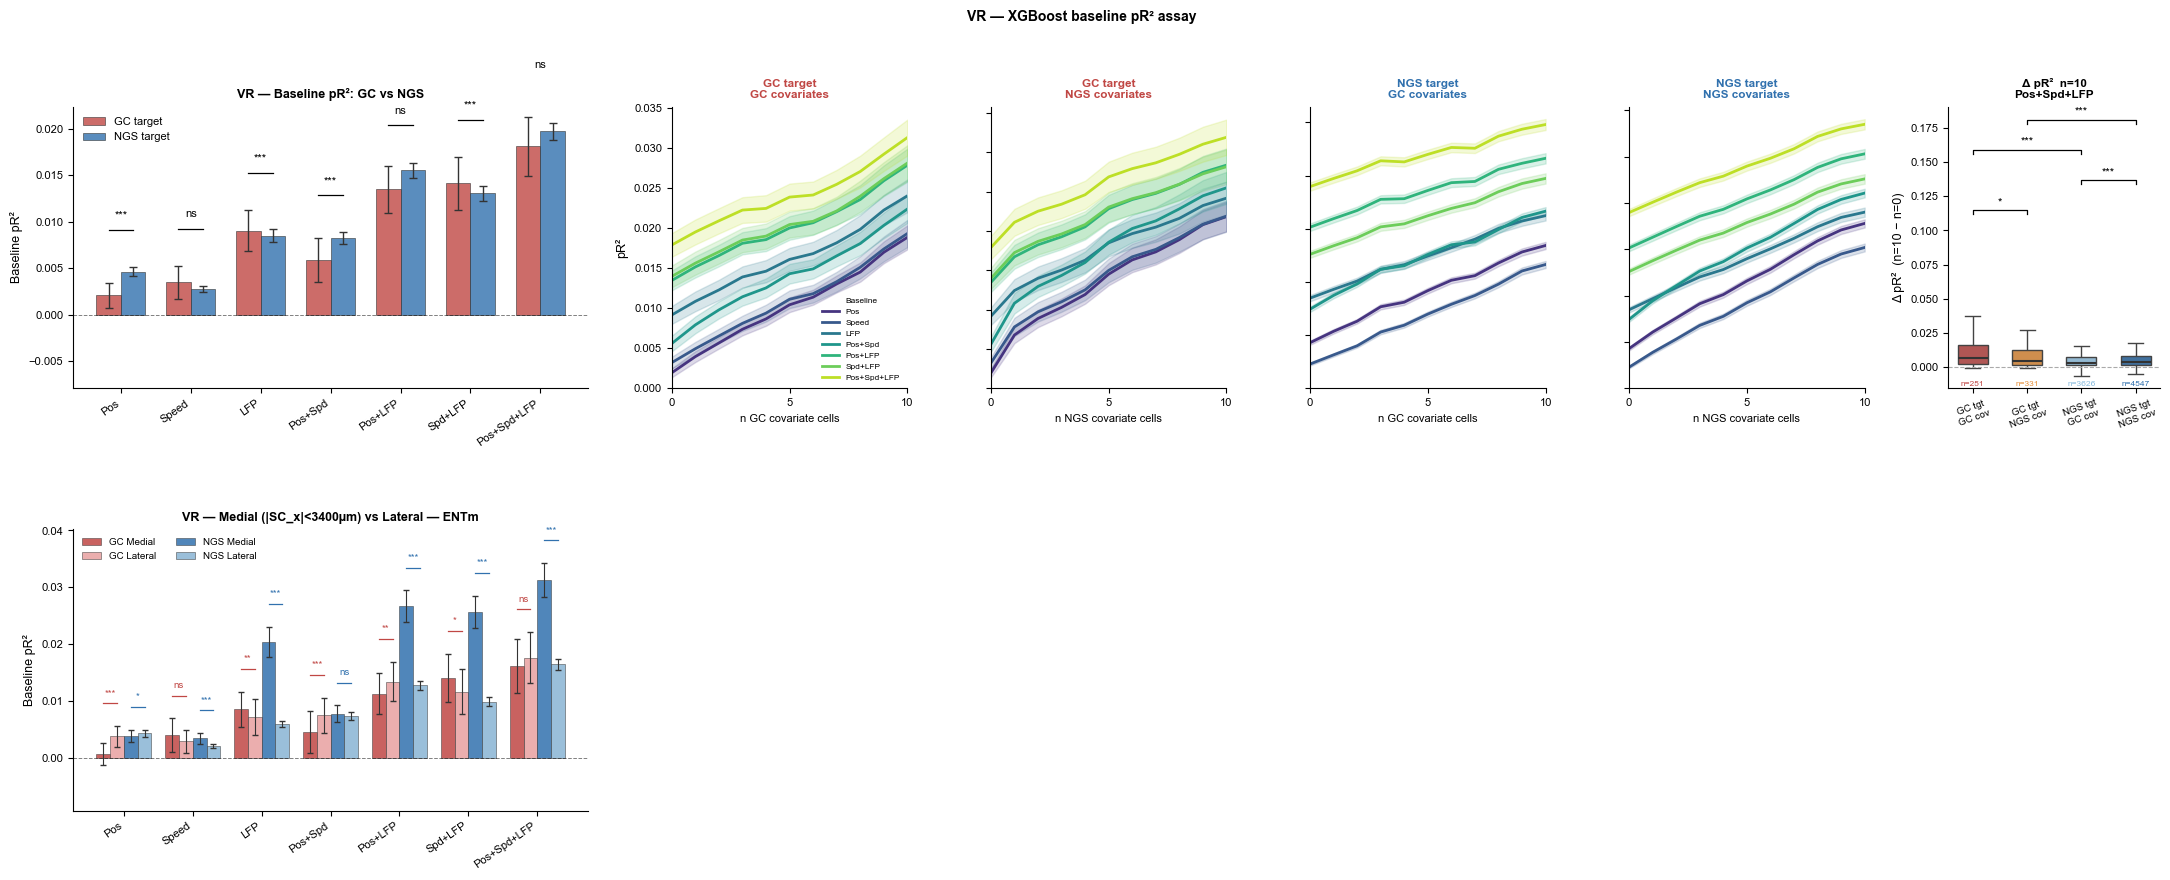

In [7]:
print('VR summary Δ pR²:')
make_session_figure(
    data          = vr_data,
    baseline_order= VR_BASELINE_ORDER,
    bl_label      = VR_BASELINE_LABEL,
    most_complex_bl = VR_MOST_COMPLEX,
    bl_palette    = VR_BL_PALETTE,
    session_label = 'VR',
    save_stem     = 'Figure4_v5_VR_baseline_assay',
)

## 7. Open Field figure

OF summary Δ pR²:
  GC→GC         n=  466  median Δ pR²=0.0103
  GC→NGS        n=  645  median Δ pR²=0.0069
  NGS→GC        n= 5394  median Δ pR²=0.0060
  NGS→NGS       n= 7115  median Δ pR²=0.0060
Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/Figure4_v5_OF_baseline_assay.pdf


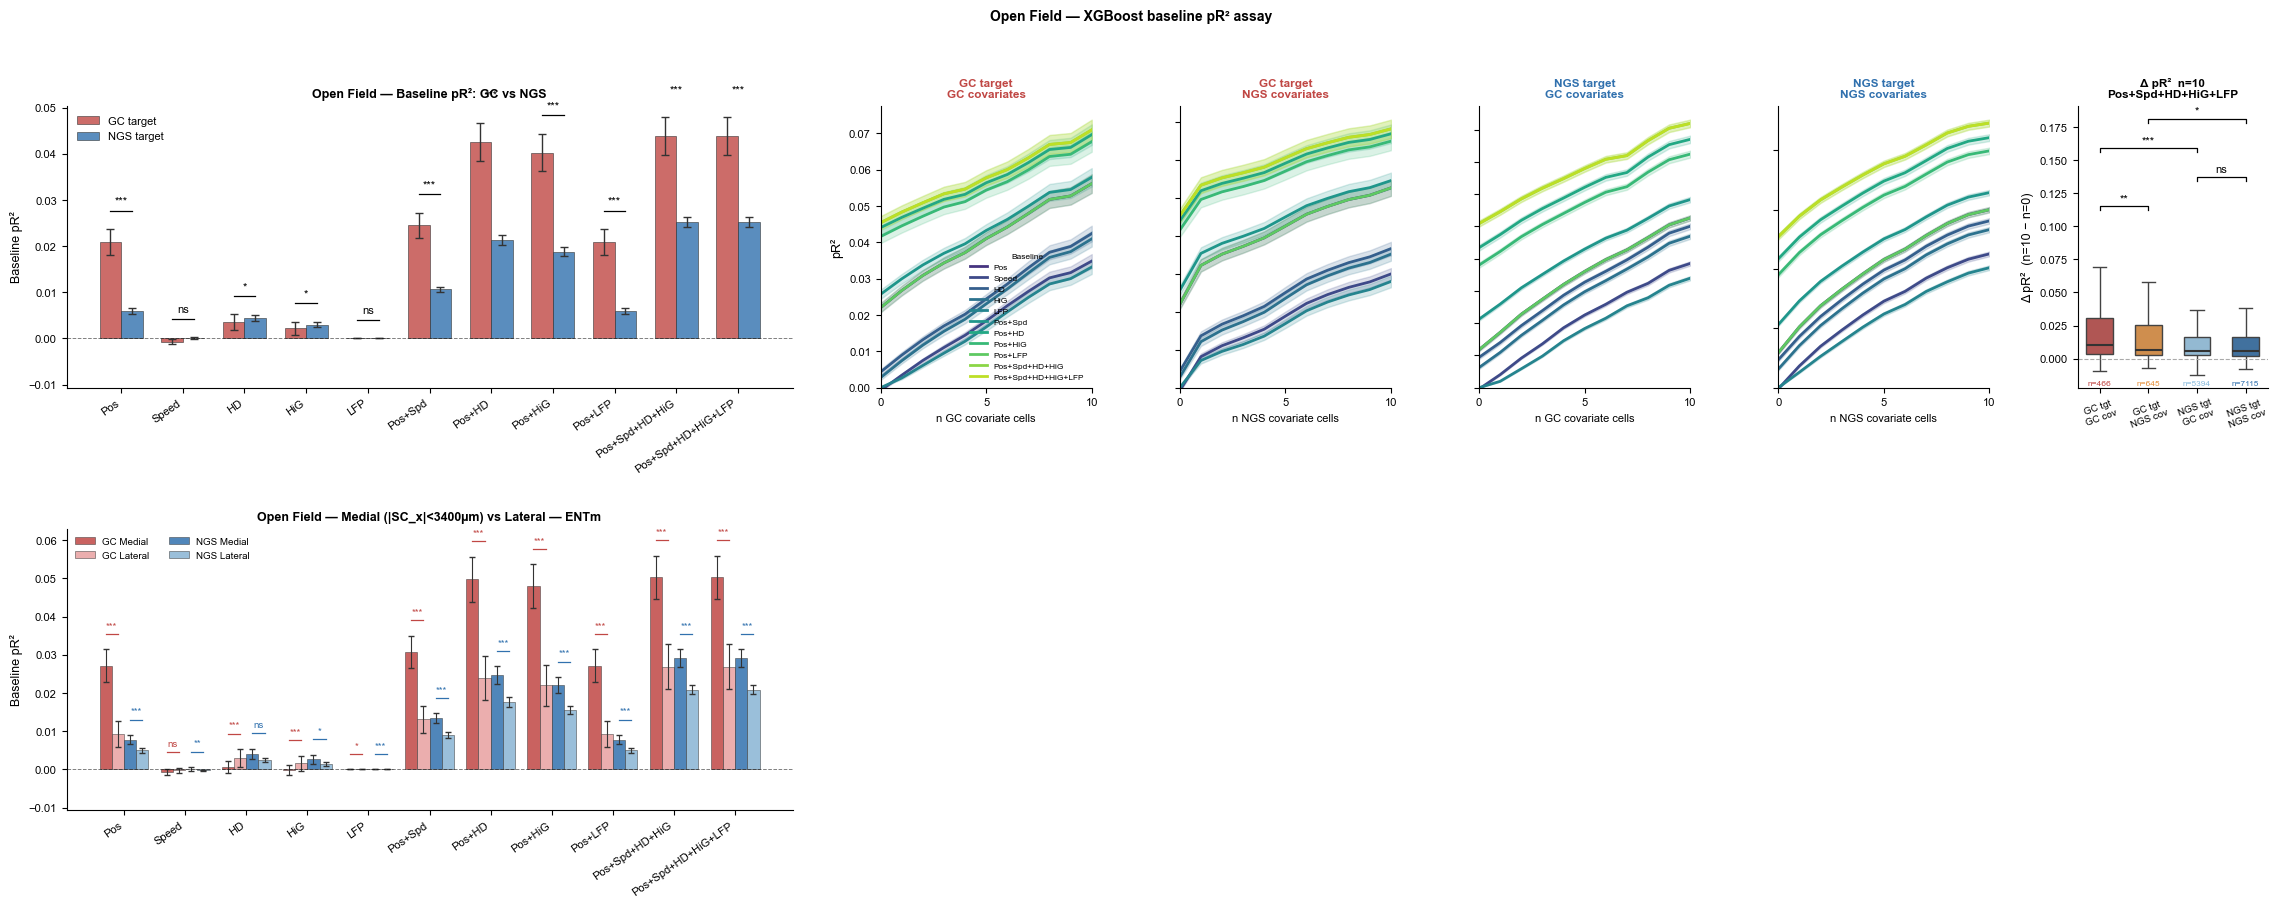

In [8]:
print('OF summary Δ pR²:')
make_session_figure(
    data          = of_data,
    baseline_order= OF_BASELINE_ORDER,
    bl_label      = OF_BASELINE_LABEL,
    most_complex_bl = OF_MOST_COMPLEX,
    bl_palette    = OF_BL_PALETTE,
    session_label = 'Open Field',
    save_stem     = 'Figure4_v5_OF_baseline_assay',
)

## 8. VR vs OF direct comparison
Side-by-side Δ pR² at n=10 for VR and OF, most complex baseline each.

Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/Figure4_v5_VR_vs_OF_comparison.pdf


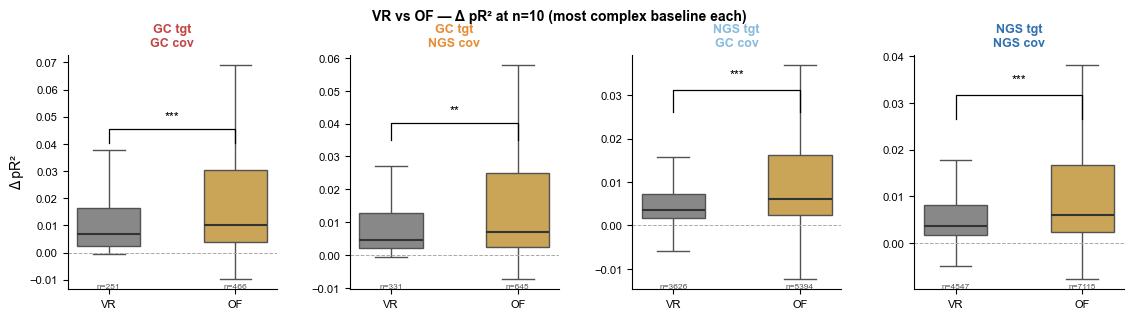

In [9]:
GROUP_ORDER = ['GC\u2192GC', 'GC\u2192NGS', 'NGS\u2192GC', 'NGS\u2192NGS']
LABEL_MAP   = {
    'GC\u2192GC':   'GC tgt\nGC cov',
    'GC\u2192NGS':  'GC tgt\nNGS cov',
    'NGS\u2192GC':  'NGS tgt\nGC cov',
    'NGS\u2192NGS': 'NGS tgt\nNGS cov',
}

vr_summary = build_summary_df(vr_data, VR_MOST_COMPLEX).assign(session='VR')
of_summary = build_summary_df(of_data, OF_MOST_COMPLEX).assign(session='OF')
both = pd.concat([vr_summary, of_summary], ignore_index=True)
both['label_short'] = both['label'].map(LABEL_MAP)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.5), sharey=False,
                          gridspec_kw=dict(wspace=0.35, left=0.09, right=0.97, top=0.85, bottom=0.18))

for ax, grp in zip(axes, GROUP_ORDER):
    sub = both[both['label'] == grp]
    sns.boxplot(data=sub, x='session', y='delta', order=['VR','OF'],
                palette={'VR': '#888888', 'OF': '#ddaa44'},
                width=0.5, showfliers=False,
                medianprops=dict(color='#333', lw=1.5), ax=ax)
    ax.axhline(0, color='#aaa', lw=0.7, ls='--')
    ax.set_title(LABEL_MAP[grp], fontsize=9, color=GROUP_COLOR[grp], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('\u0394 pR\u00b2' if grp == GROUP_ORDER[0] else '')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)

    vr_d = sub[sub['session']=='VR']['delta'].dropna()
    of_d = sub[sub['session']=='OF']['delta'].dropna()
    p    = mwu_p(vr_d, of_d)
    star = sig_star(p)
    if star:
        yb = max(vr_d.quantile(0.75), of_d.quantile(0.75)) + 0.015
        ax.plot([0,0,1,1],[yb-0.005,yb,yb,yb-0.005], color='k', lw=0.9)
        ax.text(0.5, yb+0.002, star, ha='center', va='bottom', fontsize=9)
    for xi, (sess, d) in enumerate([('VR', vr_d), ('OF', of_d)]):
        ax.text(xi, ax.get_ylim()[0], f'n={len(d)}', ha='center', va='bottom',
                fontsize=6, color='#555')

fig.suptitle(f'VR vs OF — \u0394 pR\u00b2 at n={MAX_N} (most complex baseline each)',
             fontsize=10, fontweight='bold')
out_path = os.path.join(OUT_DIR, 'Figure4_v5_VR_vs_OF_comparison.pdf')
fig.savefig(out_path, bbox_inches='tight', dpi=300)
print(f'Saved: {out_path}')
plt.show()